In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
##Loading the clean data
df=pd.read_csv('finaccess2024_cleaned.csv')
print(f" Clean data loaded : {df.shape[0]} rows {df.shape[1]} columns")

ORDER =['Improved','Stayed the same','Worsened']
COLOURS=['#2ecc71','#f39c12','#e74c3c'] #Green for improved, Amber for stayed the same and red for worsened

sns.set_theme(style='whitegrid', palette='Set2')
%matplotlib inline

 Clean data loaded : 20876 rows 28 columns


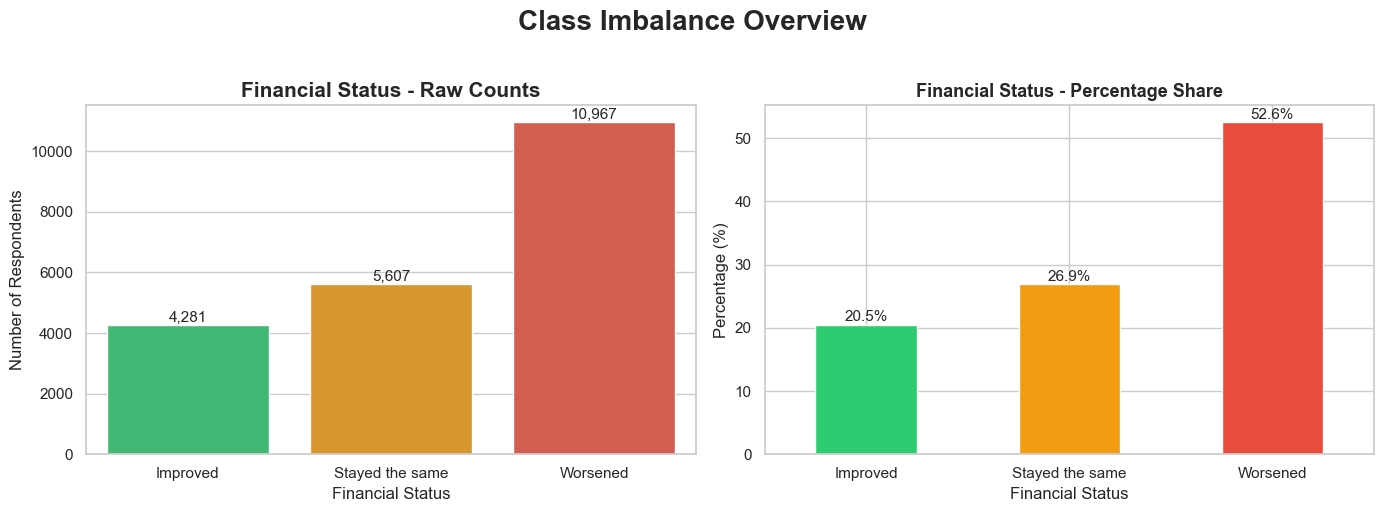

In [67]:
##Plot 1- Target Distribution

fig,axes= plt.subplots(1,2, figsize=(14,5))

sns.countplot(
    data=df,
    x='financial_status',
    order=ORDER,
    hue='financial_status',
    hue_order=ORDER,
    palette=dict(zip(ORDER,COLOURS)),
    legend=False,
    ax=axes[0]
)

axes[0].set_title('Financial Status - Raw Counts',fontsize=15, fontweight='bold')
axes[0].set_xlabel('Financial Status')
axes[0].set_ylabel('Number of Respondents')

for p in axes[0].patches:
    axes[0].annotate(
        f'{int(p.get_height()):,}',
        (p.get_x() + p.get_width() /2,
         p.get_height()),
        ha='center',va='bottom', fontsize=11
    )

pct=df['financial_status'].value_counts(normalize=True) * 100
pct = pct.reindex(ORDER)

pct.plot(kind='bar', color=COLOURS,ax=axes[1], edgecolor='white')
axes[1].set_title('Financial Status - Percentage Share', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Financial Status')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_xticklabels(ORDER, rotation=0)

#Adding pct label on each bar
for i, v in enumerate(pct):
    axes[1].text(i,v + 0.5,f'{v:.1f}%',ha='center', fontsize=11)
    
plt.suptitle('Class Imbalance Overview',fontsize=20,fontweight='bold',y=1.02)
plt.tight_layout()
# plt.savefig('plot1_target_distribution.png',dpi=150,bbox_inches='tight')
plt.show()

###Insight for the above plot


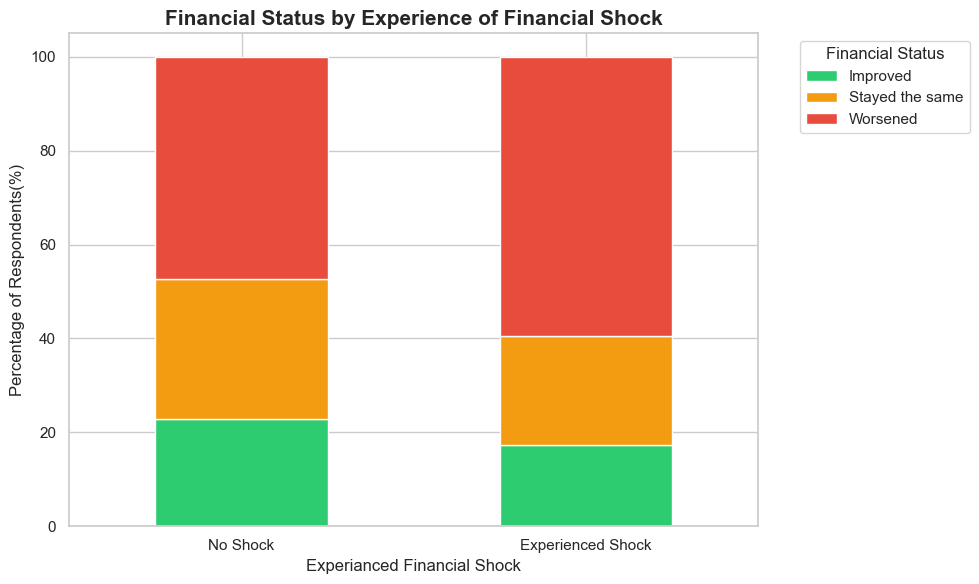


Exact percentages : 
financial_status   Improved  Stayed the same  Worsened
experienced_shock                                     
No                    22.95            29.82     47.23
Yes                   17.38            23.08     59.54


In [68]:
##Plot 2- Financial Shock Vs Financial Status
fig,ax=plt.subplots(figsize=(10,6))

shock_count = pd.crosstab(
    df['experienced_shock'],
    df['financial_status'],
    normalize='index'
)* 100

shock_count.plot(
    kind='bar',
    stacked=True,
    color=COLOURS,
    edgecolor='white',
    ax=ax
    
)
ax.set_title('Financial Status by Experience of Financial Shock',fontsize=15,fontweight='bold')
ax.set_xlabel('Experianced Financial Shock')
ax.set_ylabel('Percentage of Respondents(%)')
ax.set_xticklabels(['No Shock','Experienced Shock'], rotation=0)
ax.legend(title='Financial Status',bbox_to_anchor=(1.05, 1),loc='upper left')

plt.tight_layout()
# plt.savefig('Plot_2_Shock_vs_Status.png',dpi=150, bbox_inches='tight')
plt.show()

print(f"\nExact percentages : ")
print(f"{shock_count.round(2)}")


##Insight for the above cell

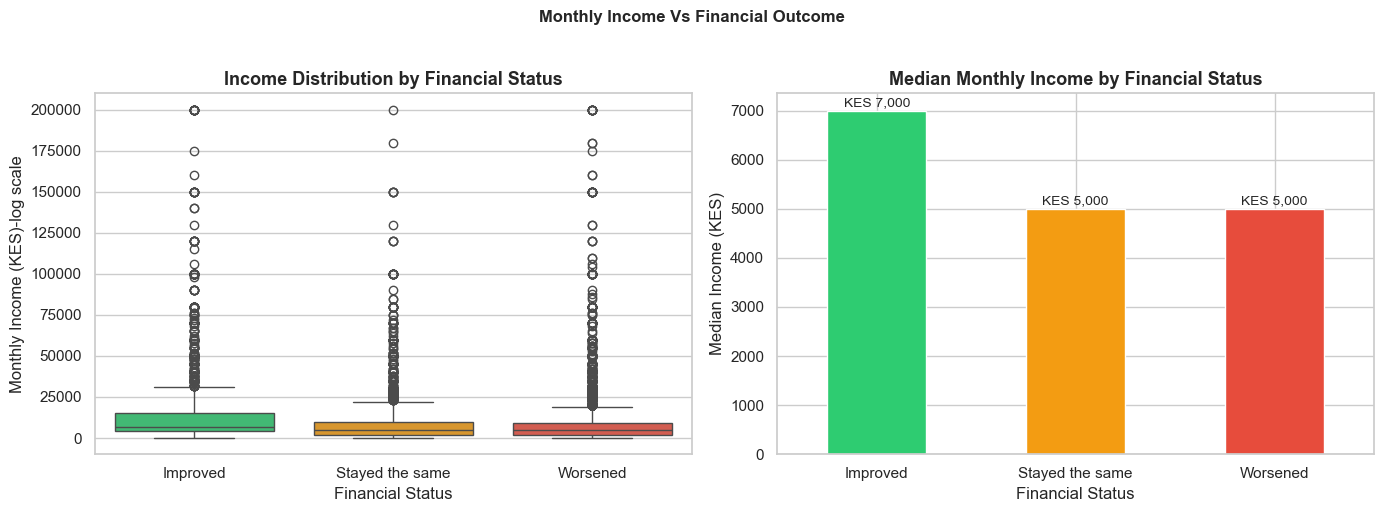


Median Income by financial status:
financial_status
Improved           7000.0
Stayed the same    5000.0
Worsened           5000.0
Name: monthly_income, dtype: float64

OUTLIER ANALYSIS Income Distribution by Financial Status

Group: Improved
  Respondents:       4,281
  Q1:                KES 4,000
  Q3:                KES 15,000
  IQR:               KES 11,000
  Lower fence:       KES -12,500
  Upper fence:       KES 31,500
  Total outliers:    452 (10.6%)
  Low outliers:      0
  High outliers:     452
  Outlier min:       KES 32,000
  Outlier max:       KES 200,000

Group: Stayed the same
  Respondents:       5,607
  Q1:                KES 2,000
  Q3:                KES 10,000
  IQR:               KES 8,000
  Lower fence:       KES -10,000
  Upper fence:       KES 22,000
  Total outliers:    473 (8.4%)
  Low outliers:      0
  High outliers:     473
  Outlier min:       KES 23,000
  Outlier max:       KES 200,000

Group: Worsened
  Respondents:       10,967
  Q1:                KES

In [69]:
##Plot3- Income Distribution by Financial Status
fig,axes=plt.subplots(1,2, figsize=(14,5))

sns.boxplot(
    data=df,
    x='financial_status',
    hue='financial_status',
    hue_order=ORDER,
    y='monthly_income',
    order=ORDER,
    palette=dict(zip(ORDER,COLOURS)),
    legend=False,
    ax=axes[0]
)
axes[0].set_ylabel('log')

axes[0].set_title('Income Distribution by Financial Status',fontsize=13, fontweight='bold')
axes[0].set_xlabel('Financial Status')
axes[0].set_ylabel('Monthly Income (KES)-log scale')

medians=df.groupby('financial_status')['monthly_income'].median()


medians=medians.reindex(ORDER)
medians.plot(kind='bar',color=COLOURS,ax=axes[1], edgecolor='white')
axes[1].set_title('Median Monthly Income by Financial Status',fontsize=13,fontweight='bold')
axes[1].set_xlabel('Financial Status')
axes[1].set_ylabel('Median Income (KES)')
axes[1].set_xticklabels(ORDER, rotation=0)

for i,v in enumerate(medians):
    axes[1].text(i,v +100, f'KES {v:,.0f}',ha='center',fontsize='10')

plt.suptitle('Monthly Income Vs Financial Outcome',fontsize=12, fontweight='bold',y=1.02)
plt.tight_layout()
#plt.savefig('plot3_income_vs_status.png',dpi=150,bbox_inches='tight')
plt.show()

print(f"\nMedian Income by financial status:")
print(medians)

print()
print("="*20)
print("OUTLIER ANALYSIS Income Distribution by Financial Status")
print("="*20)

for group in ORDER:
    group_data=df[df['financial_status']==group]['monthly_income']
    Q1=group_data.quantile(0.25)
    Q3=group_data.quantile(0.75)
    IQR=Q3-Q1
    
    lower_fence=Q1-1.5 *IQR
    upper_fence=Q3+1.5*IQR
    
    outliers=group_data[
        (group_data<lower_fence)| (group_data> upper_fence)
    ]
    low_outliers= group_data[group_data<lower_fence]
    high_outliers= group_data[group_data>upper_fence]
    
    print(f"\nGroup: {group}")
    print(f"  Respondents:       {len(group_data):,}")
    print(f"  Q1:                KES {Q1:,.0f}")
    print(f"  Q3:                KES {Q3:,.0f}")
    print(f"  IQR:               KES {IQR:,.0f}")
    print(f"  Lower fence:       KES {lower_fence:,.0f}")
    print(f"  Upper fence:       KES {upper_fence:,.0f}")
    print(f"  Total outliers:    {len(outliers):,} "
          f"({len(outliers)/len(group_data)*100:.1f}%)")
    print(f"  Low outliers:      {len(low_outliers):,}")
    print(f"  High outliers:     {len(high_outliers):,}")
    print(f"  Outlier min:       KES {outliers.min():,.0f}")
    print(f"  Outlier max:       KES {outliers.max():,.0f}")


##INSIGHT
